# Preprocessing, Ekstraksi Fitur & Upload Database — NO₂ Kedungpring

**Mata Kuliah:** Proyek Sains Data — Semester 5

**Wilayah:** Kecamatan Kedungpring, Kabupaten Lamongan

**Polutan:** NO₂

**Input:** `../data/csv/NO2-Kedungpring.csv` (hasil `ekstraksi-no2-kedungpring.ipynb`)

![alt text](img9.png)

## Import Pustaka

Selain `pandas`, `numpy`, dan `matplotlib` untuk preprocessing, notebook ini menambah
`tsfel` untuk ekstraksi fitur dan `sqlalchemy` untuk koneksi ke database Aiven.

In [10]:
import os
import inspect
from datetime import datetime

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tsfel.feature_extraction.features as tsfel_features
from sqlalchemy import create_engine, text

CSV_DIR = "../data/csv/"
FEATURE_DIR = "../data/features/"
os.makedirs(FEATURE_DIR, exist_ok=True)

target_pollutant = "NO2"
TEMPORAL_EXTENT = ["2025-08-31", "2026-08-31"]  # sama seperti Tahap 1

print("Siap memproses data:", os.path.abspath(os.path.join(CSV_DIR, "NO2-Kedungpring.csv")))

Siap memproses data: d:\Semester 5\Proyek sain data\PSD\data\csv\NO2-Kedungpring.csv


## 1. Pepocessing Data

### 1.1 Memuat Data & Melengkapi Hari yang Hilang (Reindex)

Data mentah hanya memiliki 169 baris karena observasi satelit tidak tersedia pada setiap hari. Oleh karena itu dilakukan reindex terhadap seluruh tanggal dalam periode 31 Agustus 2025 sampai 31 Agustus 2026. Proses ini menghasilkan deret waktu sebanyak 366 hari. Tanggal yang tidak memiliki observasi akan muncul sebagai nilai NaN, sehingga kondisi missing value menjadi eksplisit dan dapat ditangani pada tahap berikutnya.

In [11]:
df_raw = pd.read_csv(os.path.join(CSV_DIR, "NO2-Kedungpring.csv"))
df_raw["date"] = pd.to_datetime(df_raw["date"])
df_raw[target_pollutant] = pd.to_numeric(df_raw[target_pollutant], errors="coerce")

print(f"Jumlah baris SEBELUM reindex : {len(df_raw)}")

# Buat deret tanggal harian penuh sesuai rentang ekstraksi Tahap 1
full_date_range = pd.date_range(start=TEMPORAL_EXTENT[0], end=TEMPORAL_EXTENT[1], freq="D")

df = (
    df_raw.set_index("date")
    .reindex(full_date_range)
    .rename_axis("date")
    .reset_index()
)

print(f"Jumlah baris SETELAH reindex : {len(df)}")
print(f"Missing value setelah reindex (hari tanpa observasi satelit): {df[target_pollutant].isna().sum()}")

df.head()

Jumlah baris SEBELUM reindex : 169
Jumlah baris SETELAH reindex : 366
Missing value setelah reindex (hari tanpa observasi satelit): 197


,date,NO2
0,2025-08-31,0.000036
1,2025-09-01,0.000020
2,2025-09-02,NaN
3,2025-09-03,0.000013
4,2025-09-04,NaN


### 1.2 Deteksi Outlier — Metode IQR

Outlier dideteksi hanya dari nilai yang **valid** (bukan NaN hasil reindex), agar
batas Q1/Q3 tidak terpengaruh oleh hari-hari kosong. Outlier yang ditemukan ditandai
sebagai NaN — nantinya diisi bersamaan dengan missing value asli pada tahap
imputasi.

Outlier dideteksi menggunakan metode **Interquartile Range (IQR)**, dengan langkah:

1. Menghitung kuartil pertama ($Q_1$) dan kuartil ketiga ($Q_3$) dari data konsentrasi NO₂.
2. Menghitung IQR:

   $$IQR = Q_3 - Q_1$$

3. Menentukan batas bawah dan batas atas:

   $$\text{Batas Bawah} = Q_1 - 1.5 \times IQR$$
   $$\text{Batas Atas} = Q_3 + 1.5 \times IQR$$

4. Suatu titik data $x_i$ dikategorikan sebagai **outlier** apabila:

   $$x_i < \text{Batas Bawah} \quad \text{atau} \quad x_i > \text{Batas Atas}$$

Titik yang terdeteksi sebagai outlier kemudian ditandai sebagai nilai kosong (NaN)
dan diisi ulang pada tahap imputasi, sehingga struktur deret waktu harian tetap utuh.

In [12]:
valid_values = df[target_pollutant].dropna()

Q1 = valid_values.quantile(0.25)
Q3 = valid_values.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

is_outlier = (df[target_pollutant] < lower_bound) | (df[target_pollutant] > upper_bound)
n_outlier = is_outlier.sum()

print(f"Q1 = {Q1:.6e} | Q3 = {Q3:.6e} | IQR = {IQR:.6e}")
print(f"Batas bawah = {lower_bound:.6e} | Batas atas = {upper_bound:.6e}")
print(f"Jumlah outlier terdeteksi: {n_outlier} dari {valid_values.shape[0]} data valid")

df_before_impute = df.copy()
df_before_impute["is_outlier"] = is_outlier

df.loc[is_outlier, target_pollutant] = np.nan

Q1 = 2.437013e-05 | Q3 = 3.929275e-05 | IQR = 1.492262e-05
Batas bawah = 1.986205e-06 | Batas atas = 6.167668e-05
Jumlah outlier terdeteksi: 0 dari 169 data valid


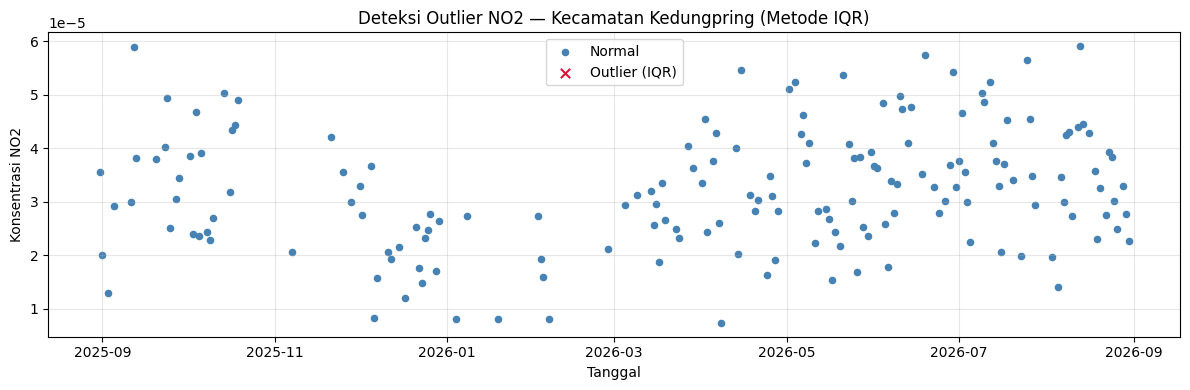

In [13]:
# Visualisasi: normal vs outlier (titik NaN hasil reindex otomatis tidak tergambar)
normal = df_before_impute[~df_before_impute["is_outlier"]]
outliers = df_before_impute[df_before_impute["is_outlier"]]

plt.figure(figsize=(12, 4))
plt.scatter(normal["date"], normal[target_pollutant], color="steelblue", s=20, label="Normal")
plt.scatter(outliers["date"], outliers[target_pollutant], color="crimson", s=45, marker="x", label="Outlier (IQR)")
plt.title(f"Deteksi Outlier {target_pollutant} — Kecamatan Kedungpring (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel(f"Konsentrasi {target_pollutant}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 1.3 Imputasi hingga 0 NaN

Dua sumber NaN — hari tanpa observasi satelit (dari reindex) dan outlier yang baru
ditandai — diisi bersamaan menggunakan interpolasi linear berbasis waktu, dilanjutkan
forward/backward fill untuk sisa NaN di ujung deret waktu. `assert` memastikan hasil
akhir benar-benar **0 NaN** sebelum lanjut ke ekstraksi fitur.

Setelah proses interpolasi, forward fill, dan backward fill dilakukan pengecekan kembali terhadap missing value. Fungsi isna().sum() digunakan untuk menghitung jumlah nilai kosong yang masih tersisa. Hasil akhir harus menunjukkan 0 missing value. Selain itu, assert digunakan sebagai validasi otomatis untuk memastikan tidak ada nilai NaN sebelum data digunakan pada tahap ekstraksi fitur.

In [14]:
df_clean = df.set_index("date").interpolate(method="time").ffill().bfill()

n_missing_after = df_clean[target_pollutant].isna().sum()
print(f"Missing value SEBELUM imputasi (reindex + outlier) : {df[target_pollutant].isna().sum()}")
print(f"Missing value SETELAH imputasi                      : {n_missing_after}")

assert n_missing_after == 0, "Masih ada NaN tersisa setelah imputasi!"
print("\nData NO2 Kedungpring sudah 100% bersih — 366 hari, 0 NaN, 0 outlier tersisa.")

df_clean = df_clean.reset_index()

clean_csv_path = os.path.join(CSV_DIR, "NO2-Kedungpring-clean.csv")
df_clean.to_csv(clean_csv_path, index=False)
print(f"Data bersih disimpan: {clean_csv_path} ({len(df_clean)} baris)")

df_clean.head()

Missing value SEBELUM imputasi (reindex + outlier) : 197
Missing value SETELAH imputasi                      : 0

Data NO2 Kedungpring sudah 100% bersih — 366 hari, 0 NaN, 0 outlier tersisa.
Data bersih disimpan: ../data/csv/NO2-Kedungpring-clean.csv (366 baris)


,date,NO2
0,2025-08-31,0.000036
1,2025-09-01,0.000020
2,2025-09-02,0.000017
3,2025-09-03,0.000013
4,2025-09-04,0.000021


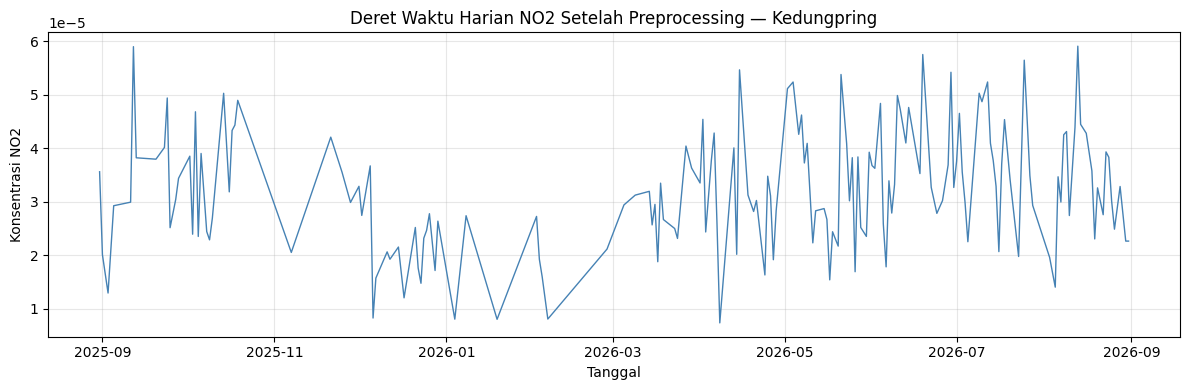

In [15]:
# Visualisasi deret waktu akhir setelah reindex + outlier ditangani + imputasi
plt.figure(figsize=(12, 4))
plt.plot(df_clean["date"], df_clean[target_pollutant], color="steelblue", linewidth=1)
plt.title(f"Deret Waktu Harian {target_pollutant} Setelah Preprocessing — Kedungpring")
plt.xlabel("Tanggal")
plt.ylabel(f"Konsentrasi {target_pollutant}")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Ekstraksi 68 Fitur dengan TSFEL

Setelah data bersih dan tidak memiliki missing value, dilakukan ekstraksi fitur menggunakan TSFEL. Sebanyak 68 fitur diekstraksi dari sinyal NO₂ yang telah melalui preprocessing. Fitur-fitur tersebut mencakup karakteristik statistik, temporal, dan spectral. Hasil ekstraksi disimpan dalam file NO2_Kedungpring_TSFEL.csv.

### 2.1 Menyiapkan Sinyal

Data harian yang sudah bersih (366 titik, 0 NaN) diambil sebagai array 1 dimensi.
`fs=1` karena sinyal ini adalah satu nilai per hari (frekuensi sampling harian).

In [16]:
fs = 1
signal_1d = df_clean[target_pollutant].astype(float).values

print(f"Panjang sinyal: {len(signal_1d)} titik data (hari)")

Panjang sinyal: 366 titik data (hari)


### 2.2 Daftar 68 Fitur & Fungsi Ekstraksi

Fitur diambil langsung dari fungsi-fungsi di `tsfel.feature_extraction.features`,
mencakup tiga domain: **statistical**, **temporal**, dan **spectral**.

In [17]:
FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()

print("Jumlah fitur yang akan diekstrak:", len(FEATURE_LIST))


def to_scalar(result):
    if isinstance(result, dict) and "values" in result:
        result = result["values"]
    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))
    return float(result)


def extract_one(fn_name, signal, fs):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters
    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)
    return to_scalar(result)


row = {}
for fn_name in FEATURE_LIST:
    try:
        row[fn_name] = extract_one(fn_name, signal_1d, fs)
    except Exception as e:
        print(f"[PERINGATAN] Gagal mengekstrak fitur '{fn_name}': {e}")
        row[fn_name] = np.nan

extracted_features_final = pd.DataFrame([row])

print(f"\nBerhasil! Jumlah fitur yang dihasilkan untuk {target_pollutant}: "
      f"{extracted_features_final.shape[1]}")
extracted_features_final

Jumlah fitur yang akan diekstrak: 68

Berhasil! Jumlah fitur yang dihasilkan untuk NO2: 68


,abs_energy,auc,autocorr,average_power,calc_centroid,calc_max,calc_mean,calc_median,calc_min,calc_std,...,spectral_spread,spectral_variation,spectrogram_mean_coeff,sum_abs_diff,wavelet_abs_mean,wavelet_energy,wavelet_entropy,wavelet_std,wavelet_var,zero_cross
0,3.702058e-07,0.010905,8.0,1.014262e-09,194.285209,0.000059,0.00003,0.00003,0.000007,0.000011,...,0.147428,0.319585,1.366946e-10,0.001801,0.000002,0.000016,2.123802,0.000016,2.814973e-10,0.0


# Deskripsi dan Perhitungan Fitur Ekstraksi Sinyal

Ekstraksi fitur dilakukan untuk mengubah sinyal mentah menjadi sejumlah karakteristik numerik yang dapat digunakan dalam proses analisis maupun klasifikasi. Fitur yang diperoleh mencakup karakteristik statistik, energi, perubahan sinyal, distribusi, frekuensi, spectral, cepstral, fractal, ECDF, dan wavelet.

Misalkan sinyal yang digunakan adalah:

$$
x_1,x_2,\ldots,x_N
$$

dengan \(N\) merupakan jumlah data/sampel dan \(\Delta t\) merupakan interval waktu antar-sampel.

---

## 1. Fitur Statistik Dasar

| Fitur                  | Deskripsi                                                        | Perhitungan                                       |               |    |
| ---------------------- | ---------------------------------------------------------------- | ------------------------------------------------- | ------------- | -- |
| `abs_energy`           | Mengukur total energi sinyal berdasarkan kuadrat amplitudo.      | \(E=\sum_{i=1}^{N}x_i^2\)                         |               |    |
| `auc`                  | Mengukur luas area di bawah kurva sinyal terhadap waktu.         | \(AUC\approx\sum_i\frac{x_i+x_{i+1}}{2}\Delta t\) |               |    |
| `average_power`        | Mengukur rata-rata energi atau kuadrat amplitudo sinyal.         | \(P=\frac{1}{N}\sum x_i^2\)                       |               |    |
| `calc_mean`            | Menunjukkan nilai rata-rata amplitudo sinyal.                    | \(\bar{x}=\frac{1}{N}\sum x_i\)                   |               |    |
| `calc_median`          | Menunjukkan nilai tengah data setelah data diurutkan.            | Nilai tengah data                                 |               |    |
| `calc_min`             | Menunjukkan nilai amplitudo paling rendah.                       | \(\min(x_i)\)                                     |               |    |
| `calc_max`             | Menunjukkan nilai amplitudo paling tinggi.                       | \(\max(x_i)\)                                     |               |    |
| `calc_std`             | Mengukur penyebaran data terhadap nilai rata-rata.               | \(\sigma=\sqrt{\frac{1}{N}\sum(x_i-\bar{x})^2}\)  |               |    |
| `calc_var`             | Mengukur varians atau tingkat penyebaran data.                   | \(Var=\frac{1}{N}\sum(x_i-\bar{x})^2\)            |               |    |
| `rms`                  | Mengukur nilai efektif amplitudo sinyal.                         | \(RMS=\sqrt{\frac{1}{N}\sum x_i^2}\)              |               |    |
| `skewness`             | Mengukur tingkat kemiringan distribusi data.                     | \(Skew=\frac{E[(x-\mu)^3]}{\sigma^3}\)            |               |    |
| `kurtosis`             | Mengukur tingkat keruncingan distribusi data.                    | \(Kurt=\frac{E[(x-\mu)^4]}{\sigma^4}\)            |               |    |
| `interq_range`         | Mengukur rentang 50% data bagian tengah.                         | \(IQR=Q_3-Q_1\)                                   |               |    |
| `hist_mode`            | Menentukan nilai atau rentang nilai yang paling sering muncul.   | Bin histogram dengan frekuensi terbesar           |               |    |
| `mean_abs_deviation`   | Mengukur rata-rata jarak absolut setiap data terhadap rata-rata. | (MAD=\frac{1}{N}\sum                              | x_i-\bar{x}   | )  |
| `median_abs_deviation` | Mengukur penyebaran data berdasarkan median.                     | (MAD_{med}=median(                                | x_i-\tilde{x} | )) |

### Contoh Perhitungan Mean

Jika terdapat data:

$$
x=[2,4,6,8]
$$

maka:

$$
Mean=\frac{2+4+6+8}{4}=5
$$

### Contoh Perhitungan RMS

$$
RMS=\sqrt{\frac{2^2+4^2+6^2+8^2}{4}}
$$

$$
RMS=\sqrt{30}=5.477
$$

---

## 2. Fitur Perubahan Sinyal

Fitur perubahan digunakan untuk mengetahui bagaimana amplitudo sinyal berubah dari satu sampel ke sampel berikutnya.

| Fitur             | Deskripsi                                               | Perhitungan                              |             |    |
| ----------------- | ------------------------------------------------------- | ---------------------------------------- | ----------- | -- |
| `mean_abs_diff`   | Rata-rata perubahan absolut antar titik data.           | (\frac{1}{N-1}\sum                       | x_{i+1}-x_i | )  |
| `mean_diff`       | Rata-rata perubahan amplitudo antar sampel.             | \(\frac{1}{N-1}\sum(x_{i+1}-x_i)\)       |             |    |
| `median_abs_diff` | Median perubahan absolut antar sampel.                  | (median(                                 | x_{i+1}-x_i | )) |
| `median_diff`     | Median perubahan amplitudo antar sampel.                | \(median(x_{i+1}-x_i)\)                  |             |    |
| `sum_abs_diff`    | Total perubahan absolut sinyal.                         | (\sum                                    | x_{i+1}-x_i | )  |
| `slope`           | Menunjukkan kecenderungan sinyal untuk naik atau turun. | Kemiringan regresi linear                |             |    |
| `distance`        | Mengukur panjang lintasan perubahan sinyal.             | \(\sum\sqrt{(\Delta t)^2+(\Delta x)^2}\) |             |    |
| `pk_pk_distance`  | Mengukur jarak antara amplitudo maksimum dan minimum.   | \(x_{max}-x_{min}\)                      |             |    |

### Contoh

Misalkan:

$$
x=[2,5,4]
$$

Perubahan antar data:

$$
[5-2,\;4-5]=[3,-1]
$$

Maka:

$$
MeanAbsDiff=\frac{|3|+|-1|}{2}=2
$$

---

## 3. Fitur Distribusi dan Kompleksitas

| Fitur            | Deskripsi                                                               | Perhitungan                                   |
| ---------------- | ----------------------------------------------------------------------- | --------------------------------------------- |
| `entropy`        | Mengukur tingkat ketidakpastian atau keragaman distribusi amplitudo.    | \(H=-\sum p_i\log(p_i)\)                      |
| `autocorr`       | Mengukur kemiripan sinyal dengan dirinya sendiri pada lag tertentu.     | \(R(k)=\sum_i(x_i-\bar{x})(x_{i+k}-\bar{x})\) |
| `dfa`            | Mengukur korelasi jangka panjang pada sinyal setelah tren dihilangkan.  | \(F(n)\propto n^\alpha\)                      |
| `hurst_exponent` | Mengukur kecenderungan pola sinyal untuk bertahan dalam jangka panjang. | \(R/S\propto n^H\)                            |
| `lempel_ziv`     | Mengukur kompleksitas pola atau urutan sinyal.                          | Berdasarkan jumlah pola baru yang ditemukan   |
| `mse`            | Mengukur rata-rata kuadrat kesalahan/perbedaan.                         | \(MSE=\frac{1}{N}\sum(x_i-\hat{x}_i)^2\)      |

### Entropy

Entropy dihitung menggunakan:

$$
H=-\sum p_i\log_2(p_i)
$$

Nilai entropy yang semakin tinggi menunjukkan distribusi sinyal yang semakin beragam atau kompleks.

---

## 4. Fitur Peak dan Turning Point

| Fitur                 | Deskripsi                                                   | Perhitungan                                         |
| --------------------- | ----------------------------------------------------------- | --------------------------------------------------- |
| `positive_turning`    | Menghitung jumlah perubahan arah yang membentuk pola naik.  | Berdasarkan perubahan tanda turunan pertama         |
| `negative_turning`    | Menghitung jumlah perubahan arah yang membentuk pola turun. | Berdasarkan perubahan tanda turunan pertama         |
| `neighbourhood_peaks` | Menghitung jumlah puncak lokal pada sinyal.                 | Membandingkan suatu titik dengan titik tetangganya  |
| `zero_cross`          | Menghitung jumlah sinyal melewati titik nol.                | Berdasarkan perubahan tanda \(x_i\) dan \(x_{i+1}\) |

### Zero Crossing

Secara sederhana:

$$
ZCR=\sum_{i=1}^{N-1}I(x_ix_{i+1}<0)
$$

Jika terjadi perubahan tanda dari positif menjadi negatif atau sebaliknya, maka terjadi satu **zero crossing**.

---

## 5. Fitur Frekuensi

Analisis frekuensi dilakukan dengan mengubah sinyal dari domain waktu ke domain frekuensi, umumnya menggunakan **Fast Fourier Transform (FFT)**.

$$
X(f)=FFT(x(t))
$$

Hasil FFT menunjukkan komponen frekuensi yang terdapat pada sinyal.

| Fitur                   | Deskripsi                                                                 | Perhitungan                                                   |      |   |
| ----------------------- | ------------------------------------------------------------------------- | ------------------------------------------------------------- | ---- | - |
| `fundamental_frequency` | Menunjukkan frekuensi dasar dari sinyal.                                  | Frekuensi dasar pada spektrum                                 |      |   |
| `max_frequency`         | Menunjukkan frekuensi dengan komponen spektrum terbesar.                  | (f_{max}=\arg\max_f                                           | X(f) | ) |
| `median_frequency`      | Frekuensi yang membagi energi spektrum menjadi dua bagian sama besar.     | Cari \(f_m\) sehingga energi di bawah dan di atasnya seimbang |      |   |
| `max_power_spectrum`    | Menunjukkan nilai daya maksimum pada spektrum.                            | \(\max(P(f))\)                                                |      |   |
| `power_bandwidth`       | Menunjukkan rentang frekuensi yang mengandung bagian utama energi sinyal. | Selisih batas frekuensi berdasarkan distribusi daya           |      |   |

---

## 6. Fitur Spectral

Fitur spectral digunakan untuk menganalisis distribusi energi sinyal pada domain frekuensi.

| Fitur                       | Deskripsi                                                                       | Perhitungan                                                  |
| --------------------------- | ------------------------------------------------------------------------------- | ------------------------------------------------------------ |
| `spectral_centroid`         | Menunjukkan pusat distribusi energi frekuensi.                                  | \(SC=\frac{\sum fP(f)}{\sum P(f)}\)                          |
| `spectral_spread`           | Mengukur penyebaran energi di sekitar spectral centroid.                        | \(SS=\sqrt{\frac{\sum P(f)(f-SC)^2}{\sum P(f)}}\)            |
| `spectral_skewness`         | Mengukur kemiringan distribusi frekuensi.                                       | Momen orde-3 terhadap centroid                               |
| `spectral_kurtosis`         | Mengukur keruncingan distribusi spektrum.                                       | Momen orde-4 terhadap centroid                               |
| `spectral_entropy`          | Mengukur ketidakaturan distribusi energi frekuensi.                             | \(H=-\sum p_f\log p_f\)                                      |
| `spectral_variation`        | Mengukur perubahan karakteristik spektrum antar bagian sinyal.                  | Perbedaan spektrum antar frame                               |
| `spectral_distance`         | Mengukur jarak atau perbedaan antar distribusi spektrum.                        | Berdasarkan perbedaan nilai spektrum                         |
| `spectral_decrease`         | Mengukur tingkat penurunan energi spektrum pada frekuensi yang semakin tinggi.  | Berdasarkan penurunan magnitudo spektrum                     |
| `spectral_slope`            | Mengukur kemiringan spektrum terhadap frekuensi.                                | Kemiringan regresi spektrum                                  |
| `spectral_roll_off`         | Menentukan frekuensi hingga sebagian besar energi spektrum telah tercapai.      | \(f_r\) ketika energi kumulatif mencapai persentase tertentu |
| `spectral_roll_on`          | Menentukan frekuensi awal ketika energi spektrum mulai mencapai batas tertentu. | Berdasarkan energi kumulatif spektrum                        |
| `spectral_positive_turning` | Menghitung perubahan arah positif pada spektrum.                                | Berdasarkan perubahan tanda selisih spektrum                 |

### Contoh Spectral Centroid

Misalkan terdapat:

| Frekuensi | Power |
| --------: | ----: |
|     10 Hz |     2 |
|     20 Hz |     3 |
|     30 Hz |     5 |

Maka:

$$
SC=\frac{10(2)+20(3)+30(5)}{2+3+5}
$$

$$
SC=\frac{230}{10}=23\ Hz
$$

Jadi pusat distribusi energi spektrum berada pada sekitar **23 Hz**.

---

## 7. Fitur Cepstral

### MFCC

`mfcc` merupakan **Mel-Frequency Cepstral Coefficients** yang digunakan untuk menggambarkan karakteristik spektrum sinyal.

Tahapan umum MFCC:

$$
Sinyal
\rightarrow FFT
\rightarrow Power\ Spectrum
\rightarrow Mel\ Filterbank
\rightarrow Log
\rightarrow DCT
\rightarrow MFCC
$$

MFCC banyak digunakan untuk menganalisis karakteristik suara dan sinyal audio.

### LPCC

`lpcc` merupakan **Linear Prediction Cepstral Coefficients**.

Prosesnya menggunakan **Linear Predictive Coding (LPC)** untuk memodelkan hubungan antara sampel saat ini dengan sampel sebelumnya.

Secara sederhana:

$$
x[n]\approx-\sum_{k=1}^{p}a_kx[n-k]
$$

Kemudian koefisien LPC dikonversi menjadi koefisien cepstral.

---

## 8. Fitur Fractal dan Kompleksitas

| Fitur                         | Deskripsi                                                                | Perhitungan                                           |
| ----------------------------- | ------------------------------------------------------------------------ | ----------------------------------------------------- |
| `higuchi_fractal_dimension`   | Mengukur kompleksitas geometris sinyal menggunakan metode Higuchi.       | Menggunakan panjang kurva pada berbagai skala         |
| `petrosian_fractal_dimension` | Mengukur kompleksitas sinyal berdasarkan jumlah perubahan tanda turunan. | Berdasarkan jumlah perubahan tanda dan panjang sinyal |
| `maximum_fractal_length`      | Mengukur panjang maksimum struktur fractal pada sinyal.                  | Berdasarkan panjang kurva pada skala tertentu         |
| `hurst_exponent`              | Mengukur sifat persistence atau anti-persistence sinyal.                 | \(R/S\propto n^H\)                                    |
| `dfa`                         | Mengukur korelasi jangka panjang setelah tren dihilangkan.               | \(F(n)\propto n^\alpha\)                              |

### Higuchi Fractal Dimension

Metode Higuchi membuat beberapa representasi sinyal berdasarkan interval \(k\), kemudian menghitung panjang kurva pada setiap skala.

Hubungan umumnya:

$$
L(k)\propto k^{-D}
$$

dengan \(D\) merupakan dimensi fractal.

Nilai yang lebih tinggi umumnya menunjukkan sinyal yang lebih kompleks.

---

## 9. Fitur ECDF

ECDF merupakan **Empirical Cumulative Distribution Function** yang menunjukkan proporsi data yang memiliki nilai kurang dari atau sama dengan nilai tertentu.

| Fitur                   | Deskripsi                                                      | Perhitungan                            |
| ----------------------- | -------------------------------------------------------------- | -------------------------------------- |
| `ecdf`                  | Menunjukkan distribusi kumulatif empiris.                      | \(F(x)=\frac{\#\{x_i\leq x\}}{N}\)     |
| `ecdf_percentile`       | Menunjukkan nilai amplitudo pada persentil tertentu.           | Nilai \(x\) dengan \(F(x)\approx p\)   |
| `ecdf_percentile_count` | Menunjukkan jumlah data hingga persentil tertentu.             | \(count\approx pN\)                    |
| `ecdf_slope`            | Menunjukkan perubahan ECDF terhadap perubahan nilai amplitudo. | \(slope=\frac{\Delta F(x)}{\Delta x}\) |

### Contoh

Jika terdapat 100 data dan 70 data memiliki nilai kurang dari atau sama dengan \(x\):

$$
ECDF(x)=\frac{70}{100}=0.7
$$

Artinya **70% data berada pada atau di bawah nilai \(x\)**.

---

## 10. Fitur Wavelet

Wavelet digunakan untuk menganalisis sinyal pada domain waktu dan frekuensi secara bersamaan.

Transformasi wavelet secara umum:

$$
W(a,b)=\frac{1}{\sqrt{|a|}}
\int x(t)\psi^*
\left(\frac{t-b}{a}\right)dt
$$

| Fitur              | Deskripsi                                             | Perhitungan                              |     |   |
| ------------------ | ----------------------------------------------------- | ---------------------------------------- | --- | - |
| `wavelet_abs_mean` | Mengukur rata-rata nilai absolut koefisien wavelet.   | (\frac{1}{N}\sum                         | W_i | ) |
| `wavelet_energy`   | Mengukur energi yang terdapat pada koefisien wavelet. | \(E_w=\sum W_i^2\)                       |     |   |
| `wavelet_entropy`  | Mengukur ketidakaturan distribusi energi wavelet.     | \(H_w=-\sum p_i\log p_i\)                |     |   |
| `wavelet_std`      | Mengukur penyebaran koefisien wavelet.                | \(\sqrt{\frac{1}{N}\sum(W_i-\bar W)^2}\) |     |   |
| `wavelet_var`      | Mengukur varians koefisien wavelet.                   | \(\frac{1}{N}\sum(W_i-\bar W)^2\)        |     |   |

### Wavelet Entropy

Jika energi wavelet dinormalisasi menjadi:

$$
p=[0.2,0.3,0.5]
$$

maka:

$$
H=-[0.2\log(0.2)+0.3\log(0.3)+0.5\log(0.5)]
$$

Semakin merata distribusi energi antar komponen wavelet, semakin tinggi nilai entropy.

---

## 11. Fitur Centroid

### `calc_centroid`

`calc_centroid` menunjukkan posisi pusat distribusi amplitudo sinyal.

Perhitungan umum:

$$
Centroid=
\frac{\sum_i i|x_i|}
{\sum_i|x_i|}
$$

Fitur ini dapat digunakan untuk mengetahui posisi rata-rata konsentrasi amplitudo pada sinyal.

---

## 12. Human Range Energy

### `human_range_energy`

Fitur ini mengukur energi sinyal yang terdapat dalam rentang frekuensi tertentu yang berkaitan dengan rentang frekuensi pendengaran manusia.

Perhitungan secara umum:

$$
E_{human}
=
\sum_{f\in[f_{low},f_{high}]}P(f)
$$

Semakin besar nilainya, semakin besar energi sinyal yang berada pada rentang frekuensi tersebut.

---

# 13. Pengelompokan Fitur

Secara keseluruhan, fitur hasil ekstraksi dapat dikelompokkan menjadi beberapa kategori:

| Kelompok               | Contoh Fitur                                                  | Tujuan                                      |
| ---------------------- | ------------------------------------------------------------- | ------------------------------------------- |
| **Statistik waktu**    | `mean`, `median`, `min`, `max`, `std`, `variance`             | Menggambarkan karakteristik dasar amplitudo |
| **Energi**             | `abs_energy`, `average_power`, `rms`                          | Mengukur kekuatan atau energi sinyal        |
| **Perubahan sinyal**   | `mean_diff`, `median_diff`, `sum_abs_diff`, `slope`           | Menggambarkan perubahan sinyal              |
| **Distribusi**         | `skewness`, `kurtosis`, `entropy`, `IQR`                      | Menggambarkan bentuk distribusi data        |
| **Peak/Turning Point** | `positive_turning`, `negative_turning`, `neighbourhood_peaks` | Mengidentifikasi perubahan arah dan puncak  |
| **Frekuensi**          | `fundamental_frequency`, `max_frequency`, `median_frequency`  | Menggambarkan karakteristik frekuensi       |
| **Spectral**           | `spectral_centroid`, `spectral_entropy`, `spectral_roll_off`  | Menganalisis distribusi energi frekuensi    |
| **Cepstral**           | `mfcc`, `lpcc`                                                | Menggambarkan karakteristik spektrum        |
| **Fractal**            | `higuchi_fractal_dimension`, `dfa`, `hurst_exponent`          | Mengukur kompleksitas dan korelasi sinyal   |
| **ECDF**               | `ecdf`, `ecdf_percentile`                                     | Menganalisis distribusi kumulatif           |
| **Wavelet**            | `wavelet_energy`, `wavelet_entropy`, `wavelet_std`            | Menganalisis sinyal pada berbagai skala     |

---

# 14. Kesimpulan

Ekstraksi fitur bertujuan mengubah sinyal mentah menjadi data numerik yang lebih informatif. Fitur statistik digunakan untuk menggambarkan karakteristik dasar sinyal, seperti nilai rata-rata, penyebaran, nilai maksimum, dan minimum. Fitur energi digunakan untuk mengetahui kekuatan sinyal, sedangkan fitur perubahan digunakan untuk melihat pola kenaikan dan penurunan sinyal.

Selanjutnya, fitur frekuensi dan spectral digunakan untuk menganalisis distribusi energi pada domain frekuensi. Fitur cepstral seperti MFCC dan LPCC digunakan untuk merepresentasikan karakteristik spektrum. Sementara itu, fitur fractal dan wavelet digunakan untuk mengetahui tingkat kompleksitas dan karakteristik sinyal pada berbagai skala.

Dengan demikian, hasil ekstraksi fitur dapat digunakan sebagai **atribut masukan pada tahap analisis data atau machine learning berikutnya**, seperti klasifikasi, clustering, maupun pengenalan pola.


### 2.3 Menyimpan Hasil Fitur

In [18]:
feature_csv_path = os.path.join(FEATURE_DIR, f"{target_pollutant}_Kedungpring_TSFEL.csv")
extracted_features_final.to_csv(feature_csv_path, index=False)
print(f"Fitur tersimpan: {feature_csv_path}")

Fitur tersimpan: ../data/features/NO2_Kedungpring_TSFEL.csv


## 3. Koneksi dengan Aiven

Hasil ekstraksi fitur kemudian diunggah ke database PostgreSQL pada Aiven menggunakan script upload_ke_aiven.py. Sebelum upload, data diberi informasi tambahan berupa kecamatan, jenis polutan, dan tanggal ekstraksi. Data kemudian disimpan ke tabel fitur_no2_kedungpring dan dilakukan verifikasi untuk memastikan data berhasil tersimpan.

![alt text](img8.png)


# Ringkasan

| Tahap | Proses | Output |
| ----- | ------ | ------ |
| 1. Preprocessing | Reindex ke 366 hari, deteksi outlier (IQR), imputasi hingga 0 NaN | `NO2-Kedungpring-clean.csv` |
| 2. Ekstraksi Fitur | 68 fitur TSFEL dari sinyal harian yang bersih | `NO2_Kedungpring_TSFEL.csv` |
| 3. Upload Database | Insert hasil fitur ke tabel Aiven | Tabel `fitur_no2_kedungpring` |
